In [1]:
# Dowload the dataset

# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")

# print("Path to dataset files:", path)
 


In [5]:

!pip install gensim sentence-transformers nltk torch


  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.5 MB ? eta -:--:--Requirement already satisfied: safetensors>=0.4.3 in /opt/anaconda3/envs/ml_tutorial_env/lib/python3.13/site-packages (from transformers<5.0.0,>=4.41.0->sentence-transformers) (0.7.0)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.4 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# 1️⃣ Download all required NLTK resources
nltk.download("punkt")        # Basic tokenizer
nltk.download("punkt_tab")    # Newer NLTK versions
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/natnaelsolomon/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/natnaelsolomon/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/natnaelsolomon/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/natnaelsolomon/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/natnaelsolomon/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [7]:
# Load dataset and remove missing values from relevant columns

df = pd.read_csv("Reviews.csv")   

df = df[["Text", "Score"]].dropna()

# Filtering neutral (score = 3)
df = df[df["Score"] != 3]

# Create binary sentiment
df["Sentiment"] = df["Score"].apply(lambda x: 1 if x > 3 else 0)

df = df.sample(50000, random_state=42)   # sample for speed
df.head()


,Text,Score,Sentiment
443593,This is a very high quality dog food with meat...,5,1
136949,I love this cake mix and the other 3 mixes as ...,5,1
520459,A nice strong brew. I am new to Keurig and hav...,4,1
219515,I just found PB2 and PB2 with chocolate and I ...,5,1
471273,Delightful mint tea as one would expect. Note ...,5,1


In [8]:
# Text preprocessing function (for TF-IDF & Word2Vec)
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    tokens = word_tokenize(text.lower()) # Convert to lowercase and tokenize
    tokens = [t for t in tokens if t.isalpha()] # Remove punctuation/numbers
    tokens = [w for w in tokens if w not in stop_words] # Remove stopwords(the, is, in, etc.)
    tokens = [lemmatizer.lemmatize(w) for w in tokens] # Lemmatization(running -> run, better -> good)
    return " ".join(tokens) # Join tokens back to string

In [9]:
# Apply preprocessing
df["Clean_Text"] = df["Text"].apply(preprocess)
df.head()

,Text,Score,Sentiment,Clean_Text
443593,This is a very high quality dog food with meat...,5,1,high quality dog food meat fruit grain dog lov...
136949,I love this cake mix and the other 3 mixes as ...,5,1,love cake mix mix well incredible amazon offer...
520459,A nice strong brew. I am new to Keurig and hav...,4,1,nice strong brew new keurig lived french press...
219515,I just found PB2 and PB2 with chocolate and I ...,5,1,found chocolate thrilled love sugary goody fan...
471273,Delightful mint tea as one would expect. Note ...,5,1,delightful mint tea one would expect note tea ...


In [10]:
# Split data into training and testing sets
X = df["Clean_Text"]
y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000) # Convert text to TF-IDF features
X_train_tfidf = tfidf.fit_transform(X_train) # Fit and transform training data
X_test_tfidf = tfidf.transform(X_test) # Transform testing data

In [12]:
# Logistic Regression Classifier
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=200) # Initialize model
log_reg.fit(X_train_tfidf, y_train) # Train model
pred_log_reg = log_reg.predict(X_test_tfidf) # Make predictions

pred_log_reg

array([1, 1, 1, ..., 1, 1, 1], shape=(10000,))

In [13]:
# SVM Classifier
from sklearn.svm import SVC
svm_clf = SVC() # Initialize model
svm_clf.fit(X_train_tfidf, y_train) # Train model
pred_svm = svm_clf.predict(X_test_tfidf) # Make predictions

pred_svm

array([1, 1, 1, ..., 1, 1, 1], shape=(10000,))

In [14]:
#  Evaluate models function
def evaluate_model(y_true, y_pred, model_name="Model"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"--- {model_name} Evaluation ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\n")


In [15]:
# Evaluating models
evaluate_model(y_test, pred_log_reg, model_name="Logistic Regression")
evaluate_model(y_test, pred_svm, model_name="SVM Classifier")

--- Logistic Regression Evaluation ---
Accuracy: 0.9152
Precision: 0.9242
Recall: 0.9801
F1 Score: 0.9513


--- SVM Classifier Evaluation ---
Accuracy: 0.9244
Precision: 0.9304
Recall: 0.9843
F1 Score: 0.9566




In [16]:
# Word2Vec Embeddings
from gensim.models import Word2Vec

sentences = [row.split() for row in df['Clean_Text']] # Prepare sentences for Word2Vec
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=3, workers=4) # Train Word2Vec model

In [17]:
# Convert reviews to average Word2Vec embeddings
def get_w2v_embeddings(text):
    words = text.split()
    embeddings = [w2v_model.wv[word] for word in words if word in w2v_model.wv]
    if embeddings:
        return np.mean(embeddings, axis=0)
    else:
        return np.zeros(w2v_model.vector_size)
    

X_train_w2v = np.array([get_w2v_embeddings(text) for text in X_train])
X_test_w2v = np.array([get_w2v_embeddings(text) for text in X_test])

In [18]:
# Linear SVM Classifier with Word2Vec

from sklearn.svm import LinearSVC
svm_w2v_clf = LinearSVC() # Initialize model
svm_w2v_clf.fit(X_train_w2v, y_train) # Train model
pred_svm_w2v = svm_w2v_clf.predict(X_test_w2v) # Make predictions

# Evaluating Word2Vec SVM model
evaluate_model(y_test, pred_svm_w2v, model_name="SVM with Word2Vec")

--- SVM with Word2Vec Evaluation ---
Accuracy: 0.8970
Precision: 0.9105
Recall: 0.9740
F1 Score: 0.9412




In [ ]:
!pip install sentence-transformers


: 

In [ ]:
%pip install tf-keras

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [19]:


# IMPORTANT: After running this cell, restart your kernel (Runtime > Restart kernel).
# Then, run the following code in a new cell (do NOT run below code before restarting):

from sentence_transformers import SentenceTransformer

bert_model = SentenceTransformer('all-MiniLM-L6-v2')

X_train_bert = bert_model.encode(list(X_train), show_progress_bar=True)
X_test_bert = bert_model.encode(list(X_test), show_progress_bar=True)


/opt/anaconda3/envs/ml_tutorial_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 313/313 [00:08<00:00, 36.92it/s]



In [20]:
svm_bert = LinearSVC()
svm_bert.fit(X_train_bert, y_train)
pred_bert = svm_bert.predict(X_test_bert)

evaluate_model(y_test, pred_bert, "BERT Embeddings + SVM")


--- BERT Embeddings + SVM Evaluation ---
Accuracy: 0.8949
Precision: 0.9108
Recall: 0.9708
F1 Score: 0.9399




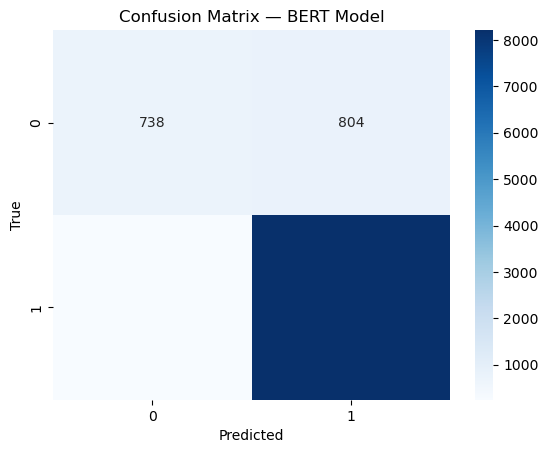

In [21]:
cm = confusion_matrix(y_test, pred_bert)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix — BERT Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
